# Narrative Miners: Uncover the Stories That Drive Markets

## Automated Analysis of Market Narratives Across Multiple Document Sources

## Why It Matters

Understanding how market narratives emerge and evolve across different information sources is crucial for investment decision-making, but manually tracking narrative development across scattered news coverage, earnings calls, and regulatory filings is time consuming. Investment decisions need systematic analysis of narrative progression to identify emerging trends and timing patterns.

## What It Does

The `NarrativeMiner` class in the bigdata-research-tools package systematically tracks narrative evolution across multiple document types using unstructured data from news, transcripts, and filings. Built for analysts, portfolio managers, and investment professionals, it transforms scattered narrative signals into quantified trend intelligence and identifies timing patterns across different information sources.

## How It Works

The `NarrativeMiner` combines **multi-source content retrieval**, **temporal narrative tracking**, and **cross-source comparative analysis** to deliver:

- **Cross-document narrative mapping** across news media, earnings calls, and SEC filings
- **Temporal evolution tracking** showing how narratives develop and change over time across sources
- **Intensity measurement** quantifying narrative prevalence and significance across document types

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing "AI Bubble Concerns" narrative as it emerges and evolves across news, earnings calls, and regulatory filings, highlighting the difference between public discourse and corporate communications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

Import the core libraries needed for narrative mining analysis, including the custom visualization and analysis tools.

In [3]:
from IPython.display import display, HTML, IFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

from src.tool import (
    load_results, 
    extract_narrative_insights,
    create_source_summary,
    display_sample_data,
    visualize_cross_source_narratives, 
    visualize_news_narrative_breakdown
)

from bigdata_research_tools.workflows.narrative_miner import NarrativeMiner
from bigdata_research_tools.excel import ExcelManager
from bigdata_client import Bigdata
from bigdata_client.daterange import RollingDateRange
from bigdata_client.models.sources import Source
from bigdata_client.models.search import DocumentType

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")



✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our narrative mining results.

In [5]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

news_results_path = f"{output_dir}/ai_bubble_news.xlsx"
transcripts_results_path = f"{output_dir}/ai_bubble_transcripts.xlsx"
filings_results_path = f"{output_dir}/ai_bubble_filings.xlsx"
visualization_path = f"{output_dir}/ai_bubble_narratives.html"

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining the Narrative Analysis Parameters

### Fixed Parameters
- **AI Bubble Narratives** (`main_narratives`): Specific narrative sentences related to AI bubble concerns
- **Common Parameters** (`common_params`): Shared configuration across all narrative miners
- **Model Selection** (`llm_model`): The LLM model used for narrative labeling and analysis
- **Time Period** (`start_date` and `end_date`): The date range over which to run the analysis
- **Rerank Threshold** (`rerank_threshold`): Cross-encoder threshold for result relevance filtering
- **Document Limits** (`document_limit`): Maximum number of documents to retrieve per query
- **Search Frequency** (`freq`): Frequency of date ranges for search operations

In [8]:
# AI Bubble Narratives
main_narratives = [
    # Complex narratives (original set)
    "Quarterly reporting creates short-term pressure that undermines long-term strategic planning",
    "Semiannual reporting would reduce administrative costs and regulatory burden on public companies",
    "Current quarterly disclosure requirements discourage companies from going public due to compliance costs",
    "European and UK markets demonstrate successful operation with semiannual reporting standards",
    "Quarterly earnings calls force executives to prioritize short-term metrics over sustainable growth",
    "Reducing reporting frequency could harm investor transparency and market oversight",
    "Less frequent financial disclosures may delay detection of corporate financial problems",
    "Quarterly reporting provides essential real-time information for investment decision-making",
    "The proposal represents necessary deregulation to enhance US capital market competitiveness",
    "Historical quarterly reporting requirements were established to protect investors during market volatility",
    "Corporate executives support reduced reporting frequency to focus on business fundamentals",
    "Institutional investors worry that semiannual reporting creates information gaps and market uncertainty",
    "The SEC is prioritizing this regulatory change despite mixed stakeholder feedback",
    "Market transparency advocates argue quarterly reports are crucial for financial risk assessment",
    "Companies may voluntarily continue quarterly reporting even if semiannual becomes standard",
    "The proposal could attract more private companies to public markets by reducing compliance burden",
    "Retail investors may lose access to timely financial information under semiannual reporting",
    "Long-Term Stock Exchange supports the shift as part of broader market reform initiatives",
    "Critics warn that reduced disclosure frequency could increase market volatility and speculation",
    "The reporting frequency debate reflects broader tensions between regulation and business flexibility",
    
    # Simple phrases for better recall
    "Trump wants to end quarterly earnings reports",
    "Companies should report twice a year instead of four times",
    "Quarterly reporting is too expensive for businesses",
    "Semiannual reporting saves money and time",
    "Europe already uses semiannual reporting successfully",
    "CEOs spend too much time on quarterly earnings",
    "Quarterly reports create short-term thinking",
    "Investors need more frequent financial updates",
    "Less reporting means less transparency",
    "Quarterly earnings help detect problems early",
    "SEC supports changing reporting rules",
    "Public companies want fewer reporting requirements",
    "Market reforms should reduce regulatory burden",
    "Investors worry about missing important information",
    "Nasdaq CEO supports reporting changes",
    "Quarterly reporting discourages IPOs",
    "Semiannual reporting follows international standards",
    "Market transparency versus business efficiency debate",
    "Reporting frequency affects stock market volatility",
    "Companies prefer focusing on long-term strategy",
    "Financial disclosure rules need modernization",
    "Trump's deregulation agenda includes reporting changes",
    "Quarterly earnings calls distract from business operations",
    "Investor protection requires frequent financial updates",
    "Compliance costs hurt small public companies"
]

# LLM Specification
llm_model = "openai::gpt-4o-mini"


# Specify Time Range
start_date = "2025-09-10"
end_date = "2025-09-19"

# Rerank Threshold
rerank_threshold = 0.7

# Search Frequency
freq = 'D'

# Fiscal Year
fiscal_year = 2025

# Document Limits
document_limit = 100

# Commen Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}

## Configure the Narrative Miners

Create narrative miners for each document type. In this example, we select MT Newswires as the news source.

In [32]:
# Common Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}
    
# Choose MT Newswires as a news source
tech_news_sources = bigdata.knowledge_graph.find_sources("MT Newswires")
tech_news_ids = [source.id for source in tech_news_sources if "MT Newswires" == source.name]

# Create the specialized miners for each document type
news_miner = NarrativeMiner(
    #sources=tech_news_ids,
    document_type=DocumentType.NEWS,
    fiscal_year=None,
    **common_params
)

transcripts_miner = NarrativeMiner(
    sources=None,
    document_type=DocumentType.TRANSCRIPTS,
    fiscal_year=fiscal_year,
    **common_params
)

filings_miner = NarrativeMiner(
    sources=None,
    fiscal_year=fiscal_year,
    document_type=DocumentType.FILINGS,
    **common_params
)

## Run Narrative Mining Across Sources

Execute the narrative mining processes for news, earnings call transcripts, and SEC filings:

In [ ]:
# Mine news narratives
print("Mining news narratives...")
try:
    news_results = news_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=news_results_path
    )
    print("✅ News mining completed successfully!")
except Exception as e:
    print(f"Warning during news mining: {e}")

Mining news narratives...


Querying OpenAI...:  52%|█████▏    | 5116/9748 [04:15<04:00, 19.30it/s]

In [20]:
len(news_results)

1

In [30]:
df = transcripts_results["df_labeled"]

df_company = df[df["Entity Type"] == "COMP"]
df_company["Entity"].value_counts()


Entity
The Artisanal Spirits Co. PLC                  21
Alithya Group Inc.                             20
Somero Enterprises Inc.                        19
Embracer Group AB                              17
Nexteq PLC                                     15
Judges Scientific PLC                          14
Amber International Holding Ltd.               13
PCI-PAL PLC                                    12
Energean PLC                                   11
Trustpilot Group PLC                           11
Vince Holding Corp.                            11
Oxford Industries Inc.                         10
Public Policy Holding Co. Inc.                 10
EKF Diagnostics Holdings PLC                   10
RF Industries Ltd.                             10
Harworth Group PLC                              9
Black Stone Minerals LP                         9
TalkPool AG                                     8
Capricorn Energy PLC                            8
Exor N.V.                                  

In [31]:
news_results["df_labeled"]

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type
0,Sep 2025,2025-09-11,C3CF962162E5E6A9F35CFD565FF1C240,C3CF962162E5E6A9F35CFD565FF1C240-3,Research Alert: CFRA Keeps Hold Opinion On Ads...,We think the plan underscores management's urg...,The sentence discusses management's focus on l...,Companies prefer focusing on long-term strategy,Profitability,None,FINC
1,Sep 2025,2025-09-11,C3CF962162E5E6A9F35CFD565FF1C240,C3CF962162E5E6A9F35CFD565FF1C240-3,Research Alert: CFRA Keeps Hold Opinion On Ads...,We think the plan underscores management's urg...,The sentence discusses management's focus on l...,Companies prefer focusing on long-term strategy,Reinvestment,None,FINC
2,Sep 2025,2025-09-11,C3CF962162E5E6A9F35CFD565FF1C240,C3CF962162E5E6A9F35CFD565FF1C240-3,Research Alert: CFRA Keeps Hold Opinion On Ads...,We think the plan underscores management's urg...,The sentence discusses management's focus on l...,Companies prefer focusing on long-term strategy,European,None,NATL
3,Sep 2025,2025-09-11,C3CF962162E5E6A9F35CFD565FF1C240,C3CF962162E5E6A9F35CFD565FF1C240-3,Research Alert: CFRA Keeps Hold Opinion On Ads...,We think the plan underscores management's urg...,The sentence discusses management's focus on l...,Companies prefer focusing on long-term strategy,Obesity,None,MDCO
4,Sep 2025,2025-09-11,C3CF962162E5E6A9F35CFD565FF1C240,C3CF962162E5E6A9F35CFD565FF1C240-3,Research Alert: CFRA Keeps Hold Opinion On Ads...,We think the plan underscores management's urg...,The sentence discusses management's focus on l...,Companies prefer focusing on long-term strategy,Franchise,None,BUSI
...,...,...,...,...,...,...,...,...,...,...,...
102,Sep 2025,2025-09-16,B0218E84EA17DA3F58BCBA49C3498F6F,B0218E84EA17DA3F58BCBA49C3498F6F-3,Commerzbank on Overnight News,Tariffs: U.S. tariffs of 15% on Japanese cars ...,The sentence mentions the SEC supporting Trump...,The SEC is prioritizing this regulatory change...,U.S. Securities and Exchange Commission,United States,ORGA
103,Sep 2025,2025-09-19,CFDA81D207FC0DFED700185A9AE380DB,CFDA81D207FC0DFED700185A9AE380DB-3,Research Alert: Lennar Suggests Margin Trough;...,We believe LEN's shift away from relentless vo...,The sentence discusses a company's strategic s...,Companies prefer focusing on long-term strategy,Interest,None,FINC
104,Sep 2025,2025-09-19,CFDA81D207FC0DFED700185A9AE380DB,CFDA81D207FC0DFED700185A9AE380DB-3,Research Alert: Lennar Suggests Margin Trough;...,We believe LEN's shift away from relentless vo...,The sentence discusses a company's strategic s...,Companies prefer focusing on long-term strategy,Investment,None,FINC
105,Sep 2025,2025-09-19,CFDA81D207FC0DFED700185A9AE380DB,CFDA81D207FC0DFED700185A9AE380DB-3,Research Alert: Lennar Suggests Margin Trough;...,We believe LEN's shift away from relentless vo...,The sentence discusses a company's strategic s...,Companies prefer focusing on long-term strategy,Cost,None,FINC


In [26]:
df = news_results["df_labeled"]
df_company = df[df["Entity Type"] == "COMP"]
df_company["Entity"].value_counts()



Entity
Cowen Inc.            6
CNBC LLC              3
Bloomberg Inc.        3
New York Times Co.    1
Name: count, dtype: int64

In [13]:
# Mine transcripts narratives
print("Mining earnings call transcripts...")
try:
    transcripts_results = transcripts_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=transcripts_results_path
    )
    print("✅ Transcripts mining completed successfully!")
except Exception as e:
    print(f"Warning during transcripts mining: {e}")

Mining earnings call transcripts...


Querying OpenAI...: 100%|██████████| 65/65 [00:05<00:00, 12.70it/s]


✅ Transcripts mining completed successfully!


In [14]:
# Mine filings narratives
print("Mining SEC filings...")
try:
    filings_results = filings_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=filings_results_path
    )
    print("✅ Filings mining completed successfully!")
except Exception as e:
    print(f"Warning during filings mining: {e}")

Mining SEC filings...


Querying OpenAI...: 100%|██████████| 1129/1129 [00:54<00:00, 20.84it/s]


Warning during filings mining: invalid literal for int() with base 10: 'unclear'


## Load and Process Results

Load the exported Excel files, clean the data, and display a summary.

In [15]:
# Load results from all three document types with labeling
news_df = load_results(news_results_path, "News Media")
transcripts_df = load_results(transcripts_results_path, "Earnings Calls")
filings_df = load_results(filings_results_path, "SEC Filings")

# Create and display summary
source_summary = create_source_summary(news_df, transcripts_df, filings_df)
display(source_summary)

# Display sample data from each source
display_sample_data(news_df, transcripts_df, filings_df)

Loaded 107 narrative records from News Media
Loaded 784 narrative records from Earnings Calls
Loaded 2645 narrative records from SEC Filings


,Source Type,Record Count,Date Range,Unique Narratives
0,News Media,107,2025-09-11 to 2025-09-19,6
1,Earnings Calls,784,2025-09-10 to 2025-09-18,9
2,SEC Filings,2645,2024-03-25 to 2025-03-28,8



======= SAMPLE NEWS NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-11,Research Alert: CFRA Keeps Hold Opinion On Ads...,Companies prefer focusing on long-term strategy,We think the plan underscores management's urg...
1,2025-09-11,Research Alert: CFRA Keeps Hold Opinion On Ads...,Companies prefer focusing on long-term strategy,We think the plan underscores management's urg...
2,2025-09-11,Research Alert: CFRA Keeps Hold Opinion On Ads...,Companies prefer focusing on long-term strategy,We think the plan underscores management's urg...



======= SAMPLE EARNINGS CALL NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
1,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
2,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."



======= SAMPLE SEC FILING NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
1,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
2,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...


## Create Narrative Visualizations

Generate comparative visualizations showing narrative evolution across sources and detailed breakdown of news narratives.

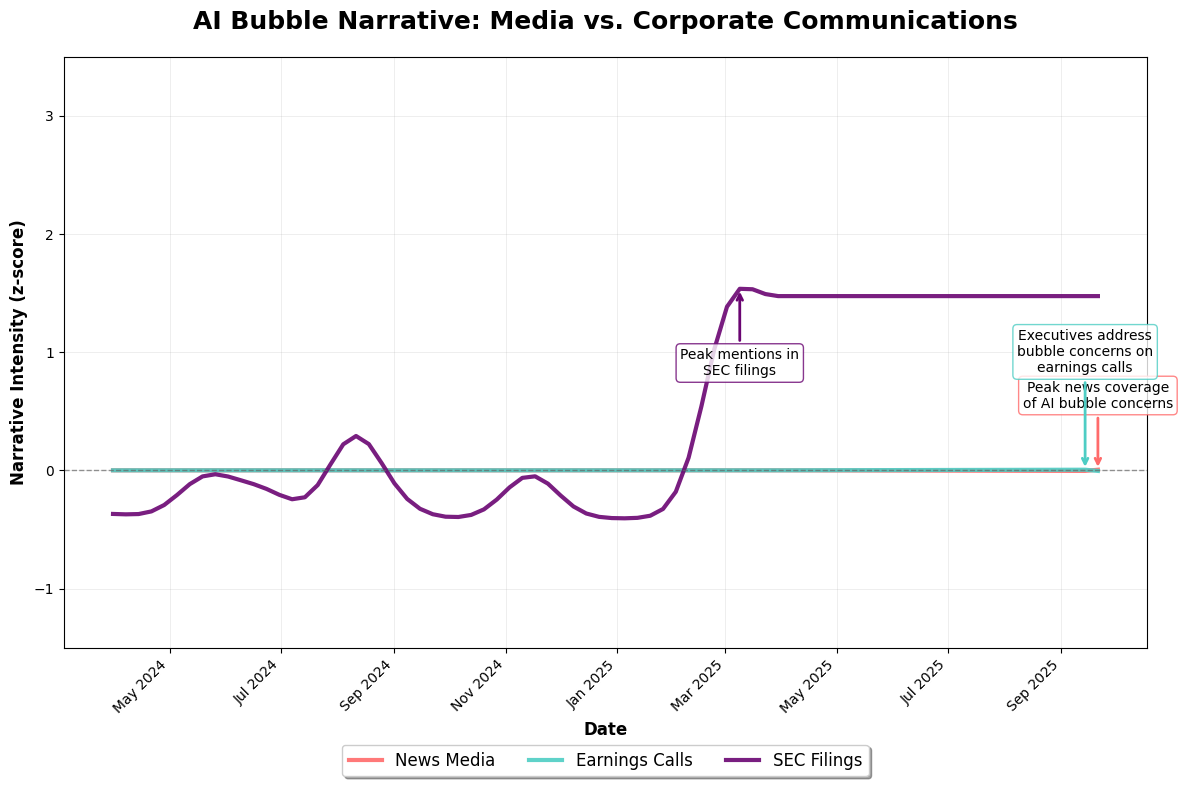

In [16]:
import warnings
warnings.filterwarnings("ignore", message=".*'method'.*", category=FutureWarning)

fig1 = visualize_cross_source_narratives(news_df, transcripts_df, filings_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig1.show()  

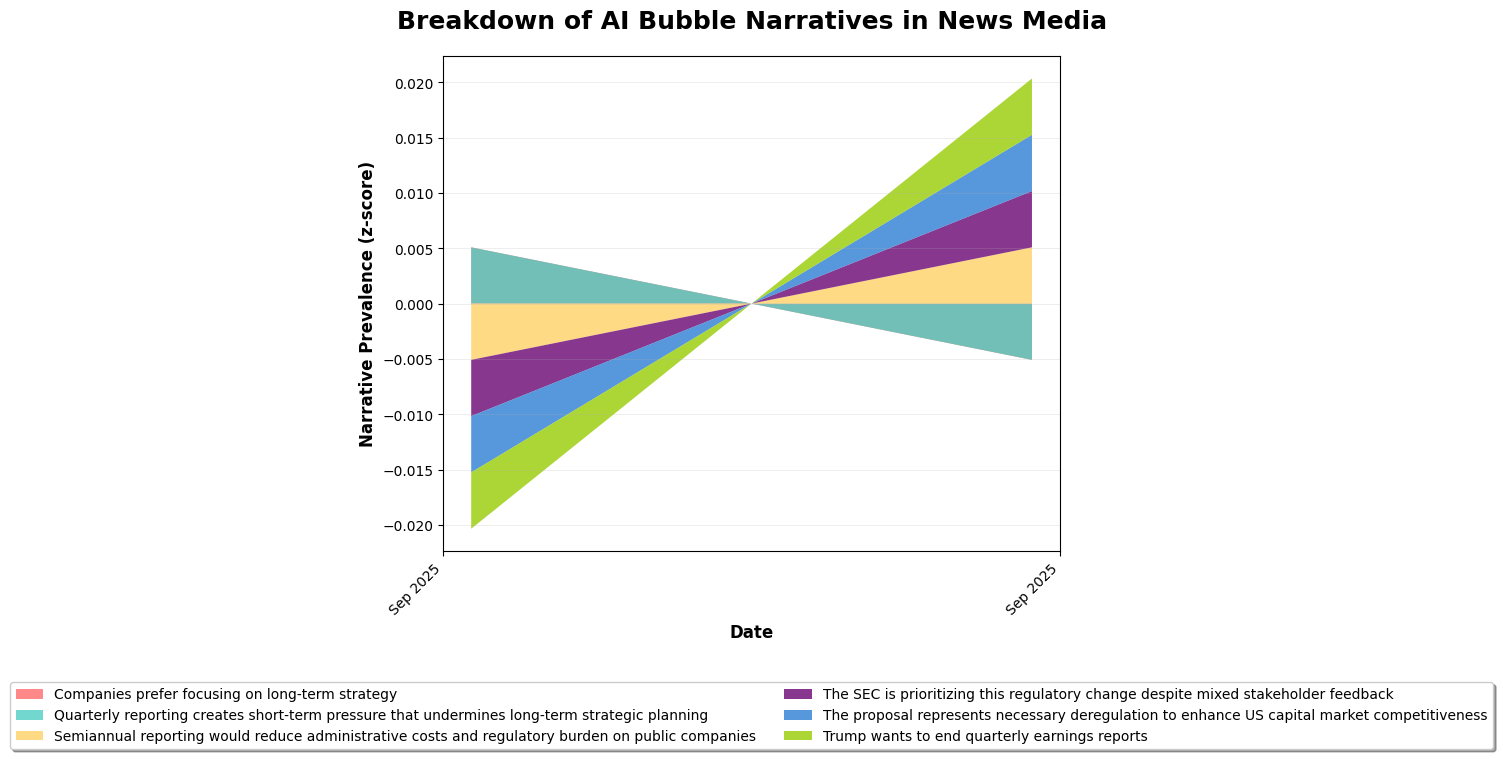

In [17]:
# Create the narrative breakdown visualization for news 
fig2 = visualize_news_narrative_breakdown(news_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig2.show()

## Extract and Display Key Insights

Extract key insights from the narrative mining data and display them.

In [18]:
# Extract insights from our narrative mining data
insights = extract_narrative_insights(news_df, transcripts_df, filings_df)

print("## AI Bubble Narrative Key Insights\n")
print(f"Peak month for news coverage: {insights['peak_news_month']}")
print(f"Peak month for earnings call mentions: {insights['peak_transcript_month']}")
print(f"Peak month for regulatory filing mentions: {insights['peak_filing_month']}")
print(f"\nDominant narrative in news: \"{insights['top_news_narrative']}\"")
print(f"Dominant narrative in earnings calls: \"{insights['top_transcript_narrative']}\"")
print(f"Dominant narrative in regulatory filings: \"{insights['top_filing_narrative']}\"")
print(f"\nTotal narrative mentions in news: {insights['total_news_mentions']}")
print(f"Total mentions in earnings calls: {insights['total_transcript_mentions']}")
print(f"Total mentions in regulatory filings: {insights['total_filing_mentions']}")
print(f"\nAverage lag between news coverage peaks and SEC filings: {insights['avg_lag_days']} days")

## AI Bubble Narrative Key Insights

Peak month for news coverage: September 2025
Peak month for earnings call mentions: September 2025
Peak month for regulatory filing mentions: March 2025

Dominant narrative in news: "The proposal represents necessary deregulation to enhance US capital market competitiveness"
Dominant narrative in earnings calls: "Companies prefer focusing on long-term strategy"
Dominant narrative in regulatory filings: "Current AI investments may not generate predicted financial returns"

Total narrative mentions in news: 107
Total mentions in earnings calls: 784
Total mentions in regulatory filings: 2645

Average lag between news coverage peaks and SEC filings: -178 days


## Export the Results

Export the data as Excel files for further analysis or to share with the team.

In [19]:
try:
    # Create the Excel manager
    excel_manager = ExcelManager()

    # Define the dataframes and their sheet configurations
    df_args = [
        (news_df, "News Narratives", (0, 0)),
        (transcripts_df, "Earnings Call Narratives", (0, 0)),
        (filings_df, "SEC Filing Narratives", (0, 0)),
        (source_summary, "Summary", (1, 1))
    ]

    # Save the workbook
    combined_results_path = f"{output_dir}/ai_bubble_narrative_analysis.xlsx"
    excel_manager.save_workbook(df_args, combined_results_path)
    
    print(f"✅ Results exported to {combined_results_path}")

except Exception as e:
    print(f"Warning while exporting to excel: {e}")

✅ Results exported to output/ai_bubble_narrative_analysis.xlsx


## Conclusion

The Narrative Miners reveal important patterns in how the AI bubble narrative evolved across information sources:

**Timing and Intensity Variations:**

- News media shows major spikes in AI bubble concerns, often leading the narrative cycle with the highest peaks
- Earnings calls demonstrate cyclical attention to bubble concerns, with executives addressing topics most prominently during specific quarters
- SEC filings show the most volatile pattern with multiple significant spikes, suggesting ongoing regulatory concerns

**Narrative Progression:**

- Media coverage often leads the initial bubble narrative, potentially triggering corporate responses visible in earnings calls
- Corporate executives' discussions peak during specific periods but tend to diminish over time
- SEC filing mentions frequently show increased intensity throughout the analysis period, indicating persistent regulatory attention

**Cross-Source Intelligence:**

- Different sources provide complementary perspectives on the same underlying narrative
- Timing lags between sources reveal information flow patterns and decision-making hierarchies
- The intensity patterns help identify when narratives are gaining or losing momentum across different stakeholder groups

This analysis demonstrates how systematic narrative mining across multiple document types provides richer insights than analyzing any single source in isolation.